In [ ]:
import numpy as np #works with array and matrices . perform mathematical analysis
import pandas as pd   # used for data handling and analysis (reads , clean ,provide dataframe)
from sklearn.preprocessing import StandardScaler  #used to scale big values so they have mean=0 & standard deviation=1 (mandatory before svm)
from sklearn.model_selection import train_test_split # splits data for trainig and testing
from sklearn import svm # finds the optimal decision boundary to seperate two planes
from sklearn.metrics import accuracy_score # Measures how many predictions were correct.

In [ ]:
diabetes_dataset = pd.read_csv('diabetes.csv')

In [ ]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_dataset.shape

(768, 9)

In [ ]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#counts the number of positive and negative cases
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
# used to check the mean value of diabetic and non-diabetic colums
diabetes_dataset.groupby('Outcome').mean()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
#seperating data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1) # axis=1 means whole colums
Y = diabetes_dataset['Outcome']

In [ ]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


**Train Test Split**

In [ ]:
X_train, X_test ,Y_train, Y_test = train_test_split( X , Y , test_size=0.3 , stratify=Y , random_state=2)
# random state=2 is for same selection of data everytime we train it
# stratify = Y to Original dataset: 90 Pass 10 Fail; Random split might give:
# Train: 90 Pass, 0 Fail ;Test: 0 Pass, 10 Fail

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (537, 8) (231, 8)


**Standardizing data**

In [ ]:
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)  # learn scaling from training data
# X_test = scaler.transform(X_test)        # apply same scaling to test data


In [ ]:
# standardized_data = scaler.fit_transform(X)  # values in similar range

In [ ]:
# print(standardized_data)

In [ ]:
# X = standardized_data
# Y = diabetes_dataset['Outcome']

In [ ]:
print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


**Training the data**

In [ ]:
classifier = svm.SVC(kernel='linear')  # defining which algo to use i.e. by line or plane

In [ ]:
# training the svm classifier
classifier.fit(X_train, Y_train)  #Use X_train and their correct answers Y_train to learn how to classify

SVC(kernel='linear')

In [ ]:
# accuracy score on training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [ ]:
print('Accuracy sore is : ', training_data_accuracy)

Accuracy sore is :  0.7802607076350093


In [ ]:
# accuracy score on test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [ ]:
print('Accuracy score is: ', test_data_accuracy)

Accuracy score is:  0.7802607076350093


In [ ]:
input_data = (7,147,76,0,0,39.4,0.257,43)
# changing the input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)
# reshaping the data
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
#standardize the input data
# std_data = scaler.transform(input_data_reshaped)
print(input_data_reshaped)

prediction = classifier.predict(input_data_reshaped)

if prediction == 0:
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[  7.    147.     76.      0.      0.     39.4     0.257  43.   ]]
The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

In [ ]:
filename = 'diabetes_model.sav'
pickle.dump(classifier, open(filename, 'wb'))


In [ ]:
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

NameError: name 'pickle' is not defined

In [ ]:
for column in X.columns:
  print(column)

**logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Logistic Regression Training Accuracy:', training_data_accuracy)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Logistic Regression Test Accuracy:', test_data_accuracy)

Logistic Regression Training Accuracy: 0.7802607076350093
Logistic Regression Test Accuracy: 0.7748917748917749


**random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, Y_train)

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Random Forest Training Accuracy:', training_data_accuracy)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Random Forest Test Accuracy:', test_data_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.7489177489177489


In [ ]:
import pandas as pd

# ---------------- LOAD DATA ----------------
# Replace with your file paths
diabetes = pd.read_csv("diabetes.csv")
heart = pd.read_csv("heart.csv")
parkinson = pd.read_csv("parkinsons.csv")

# ---------------- FUNCTION ----------------
def analyze_dataset(df, target_column, dataset_name):
    print(f"\n===== {dataset_name} Dataset Analysis =====\n")

    # Drop target column
    df = df.drop(columns=[target_column])

    # Select only numeric columns
    df = df.select_dtypes(include=['number'])

    # Create summary table
    summary = pd.DataFrame({
        'Minimum': df.min(),
        'Maximum': df.max(),
        'Average': df.mean()
    })

    print(summary)


# ---------------- RUN FOR EACH ----------------
analyze_dataset(diabetes, 'Outcome', 'Diabetes')
analyze_dataset(heart, 'target', 'Heart Disease')
analyze_dataset(parkinson, 'status', 'Parkinson')


===== Diabetes Dataset Analysis =====

                          Minimum  Maximum     Average
Pregnancies                 0.000    17.00    3.845052
Glucose                     0.000   199.00  120.894531
BloodPressure               0.000   122.00   69.105469
SkinThickness               0.000    99.00   20.536458
Insulin                     0.000   846.00   79.799479
BMI                         0.000    67.10   31.992578
DiabetesPedigreeFunction    0.078     2.42    0.471876
Age                        21.000    81.00   33.240885

===== Heart Disease Dataset Analysis =====

          Minimum  Maximum     Average
age          29.0     77.0   54.434146
sex           0.0      1.0    0.695610
cp            0.0      3.0    0.942439
trestbps     94.0    200.0  131.611707
chol        126.0    564.0  246.000000
fbs           0.0      1.0    0.149268
restecg       0.0      2.0    0.529756
thalach      71.0    202.0  149.114146
exang         0.0      1.0    0.336585
oldpeak       0.0      6.2    

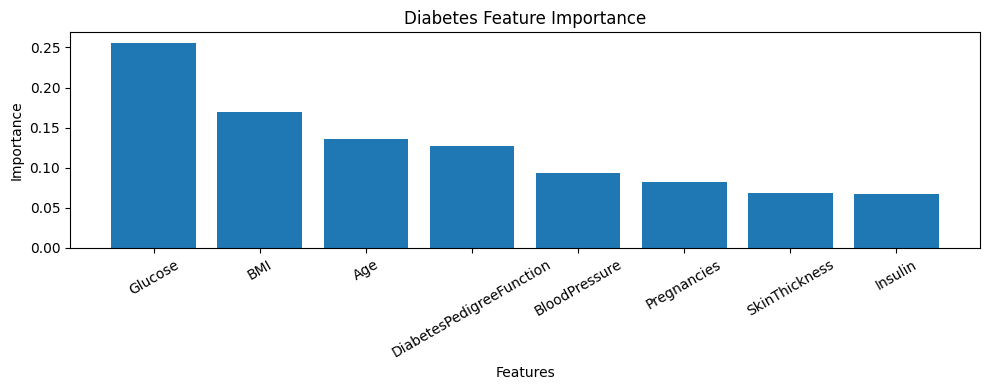

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Load dataset
diabetes = pd.read_csv("diabetes.csv")

# Prepare data
X = diabetes.drop(columns=['Outcome'])
Y = diabetes['Outcome']

# Train model
model = RandomForestClassifier(n_estimators=100)
model.fit(X, Y)

# Feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# OPTIONAL: Take top features only (better for paper)
feature_importance = feature_importance.head(8)

# ---------------- GRAPH ----------------
plt.figure(figsize=(10, 4))  # 👈 RECTANGLE (width=10, height=4)

plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Diabetes Feature Importance')

plt.xticks(rotation=30)  # less rotation looks cleaner

plt.tight_layout()  # 👈 removes extra spacing

plt.show()